<a href="https://colab.research.google.com/github/anitabudhiraja/DeepLearning/blob/main/Computational_Graphs_%26_Linear_Regression_(TensorFlow).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Topic:** Computational Graphs & Linear Regression (TensorFlow)

### Objective (CO1)
Understand:
- TensorFlow basics (Variables, operations)
- Computational graphs using `@tf.function`
- Loss functions (MSE)
- Custom Gradient Descent
- TensorBoard for visualization

### Dataset
Synthetic linear data: **y = 3x + 2 + noise**


In [1]:
# Setup
%load_ext tensorboard

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import datetime

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


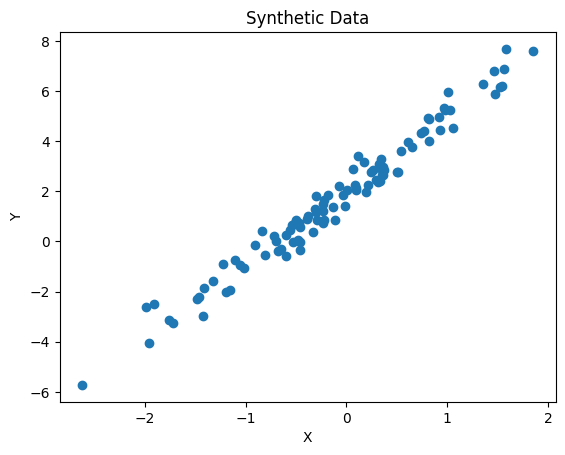

In [2]:
# Generate synthetic dataset
np.random.seed(42)
tf.random.set_seed(42)

X_np = np.random.randn(100).astype(np.float32)
noise = np.random.randn(100).astype(np.float32) * 0.5
Y_np = 3 * X_np + 2 + noise

# Plot dataset
plt.scatter(X_np, Y_np)
plt.title("Synthetic Data")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

# Convert to tensors
X = tf.constant(X_np)
Y = tf.constant(Y_np)

In [3]:
# Define model parameters
W = tf.Variable(0.0, name="Weight")
b = tf.Variable(0.0, name="Bias")

# Model: y = Wx + b
def model(x):
    return W * x + b

In [4]:
# Mean Squared Error loss
def mse_loss(y_pred, y_true):
    return tf.reduce_mean(tf.square(y_pred - y_true))

In [5]:
# TensorBoard setup
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
writer = tf.summary.create_file_writer(log_dir)

In [6]:
learning_rate = 0.1

# Convert to computational graph
@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        y_pred = model(x)
        loss = mse_loss(y_pred, y)

    dW, db = tape.gradient(loss, [W, b])

    W.assign_sub(learning_rate * dW)
    b.assign_sub(learning_rate * db)

    return loss

In [7]:
# Enable graph tracing
tf.summary.trace_on(graph=True)

epochs = 50

for epoch in range(epochs):
    loss = train_step(X, Y)

    with writer.as_default():
        tf.summary.scalar("Loss", loss, step=epoch)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.numpy():.4f}, W: {W.numpy():.4f}, b: {b.numpy():.4f}")

# Export computational graph
with writer.as_default():
    tf.summary.trace_export(name="linear_regression_graph", step=0)

print("Training Done")

Epoch 10, Loss: 0.6795, W: 2.3679, b: 1.6810
Epoch 20, Loss: 0.2363, W: 2.8232, b: 1.9487
Epoch 30, Loss: 0.2214, W: 2.9088, b: 1.9940
Epoch 40, Loss: 0.2209, W: 2.9248, b: 2.0020
Epoch 50, Loss: 0.2209, W: 2.9277, b: 2.0034
Training Done


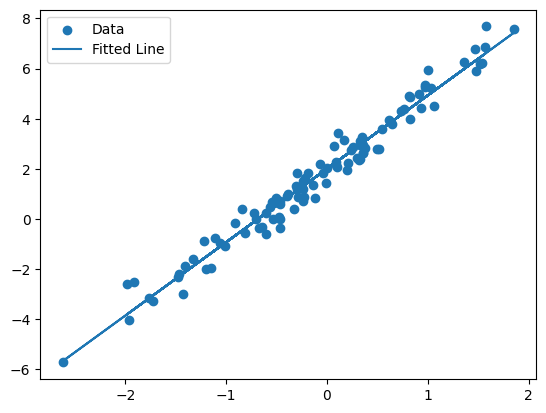

In [8]:
# Final visualization
Y_pred = model(X).numpy()

plt.scatter(X_np, Y_np, label="Data")
plt.plot(X_np, Y_pred, label="Fitted Line")
plt.legend()
plt.show()

In [9]:
# Launch TensorBoard (Try uncommenting this line on google colab and run this cell)
# %tensorboard --logdir logs/fit